# Predicción de Abandono de Clientes en Telecomunicaciones

## Notebook 2 - Análisis Exploratorio de Datos

### Objetivo del notebook

En este notebook se analizarán las principales características del conjunto de datos con el objetivo de identificar patrones, relaciones entre variables y factores que puedan influir en el abandono de clientes.

---

## Desarrollo
### Importaciones

In [1]:
# Importación de librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Funciones auxiliares

In [2]:
def tabla_porcentajes(variable):
    """
    Devuelve el porcentaje de clientes que permanecen y abandonan
    para una variable categórica.
    """
    return (
        pd.crosstab(
            df[variable],
            df["Abandono"],
            normalize="index"
        ) * 100
    ).round(2)

In [3]:
# Carga del conjunto de datos
df = pd.read_csv("../data/processed/telco_limpio.csv")

In [4]:
# Traducción de valores categóricos
df["Genero"] = df["Genero"].replace({
    "Female": "Mujer",
    "Male": "Hombre"
})

In [5]:
# Exploración inicial
df.head()

,ID_Cliente,Genero,Adulto_Mayor,Tiene_Pareja,Tiene_Dependientes,Antiguedad_Meses,Servicio_Telefono,Multiples_Lineas,Servicio_Internet,Seguridad_Online,...,Proteccion_Dispositivo,Soporte_Tecnico,Streaming_TV,Streaming_Peliculas,Tipo_Contrato,Factura_Electronica,Metodo_Pago,Cargo_Mensual,Cargos_Totales,Abandono
0,7590-VHVEG,Mujer,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Hombre,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Hombre,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Hombre,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Mujer,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


¿Cuál es el tamaño del conjunto de datos con el que vamos a trabajar?

In [6]:
df.shape

(7043, 21)

Pregunta de negocio

¿Qué tipo de variables contiene el conjunto de datos y existen problemas de calidad evidentes?

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID_Cliente              7043 non-null   str    
 1   Genero                  7043 non-null   str    
 2   Adulto_Mayor            7043 non-null   int64  
 3   Tiene_Pareja            7043 non-null   str    
 4   Tiene_Dependientes      7043 non-null   str    
 5   Antiguedad_Meses        7043 non-null   int64  
 6   Servicio_Telefono       7043 non-null   str    
 7   Multiples_Lineas        7043 non-null   str    
 8   Servicio_Internet       7043 non-null   str    
 9   Seguridad_Online        7043 non-null   str    
 10  Copia_Seguridad_Online  7043 non-null   str    
 11  Proteccion_Dispositivo  7043 non-null   str    
 12  Soporte_Tecnico         7043 non-null   str    
 13  Streaming_TV            7043 non-null   str    
 14  Streaming_Peliculas     7043 non-null   str    
 15

### 1. Estructura y tipos de datos

#### ¿Qué tipo de variables contiene el conjunto de datos y presenta problemas de calidad?

Se analiza la estructura del dataset para conocer el tipo de datos de cada variable, comprobar la existencia de valores nulos y verificar que las transformaciones realizadas durante la fase de preparación se han aplicado correctamente.

---

#### Interpretación

El conjunto de datos está formado por **7.043 registros** y **21 variables**.

Se identifican tres tipos de datos:

- **17 variables categóricas** (`object`)
- **2 variables enteras** (`int64`)
- **2 variables numéricas decimales** (`float64`)

Todas las variables contienen **7.043 valores no nulos**, por lo que el conjunto de datos no presenta valores faltantes.

Además, la variable **Cargos_Totales**, que originalmente se encontraba almacenada como texto, ha sido convertida correctamente al tipo `float64` durante la fase de preparación de los datos.

---

#### Conclusión

El conjunto de datos presenta una estructura consistente y no muestra problemas de calidad que impidan comenzar el análisis exploratorio.

In [8]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Adulto_Mayor,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
Antiguedad_Meses,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
Cargo_Mensual,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
Cargos_Totales,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


### 2. Estadísticas descriptivas de las variables numéricas

#### ¿Qué información proporciona el resumen estadístico de las variables numéricas?

Se analizan las principales medidas descriptivas de las variables numéricas para conocer su distribución, variabilidad y posibles valores extremos antes de comenzar el análisis gráfico.

---

#### Interpretación

El conjunto de datos contiene cuatro variables numéricas:

- **Adulto_Mayor**
- **Antiguedad_Meses**
- **Cargo_Mensual**
- **Cargos_Totales**

Los resultados muestran lo siguiente:

- **Adulto_Mayor** es una variable binaria (0 = No, 1 = Sí). La media (0,16) indica que aproximadamente el **16 % de los clientes son adultos mayores**.

- **Antiguedad_Meses** presenta una media de **32,37 meses**, aunque existe una elevada dispersión (desviación estándar de 24,56 meses), lo que indica que conviven clientes muy recientes con otros que llevan muchos años en la compañía.

- **Cargo_Mensual** tiene una media de **64,76 €**, con valores comprendidos entre **18,25 € y 118,75 €**, reflejando una amplia variedad de tarifas contratadas.

- **Cargos_Totales** muestra una gran variabilidad, con importes desde **0 €** hasta **8.684,80 €**. Esta dispersión es coherente con la diferencia en la antigüedad de los clientes, ya que quienes llevan más tiempo acumulan un mayor importe facturado.

---

#### Conclusión

Las variables numéricas presentan una elevada variabilidad, especialmente **Antiguedad_Meses** y **Cargos_Totales**, lo que hace recomendable estudiar posteriormente sus distribuciones mediante gráficos para detectar posibles asimetrías, concentraciones de valores o valores atípicos.

### 3. Análisis de la variable objetivo:
### Abandono

##### ¿Qué proporción de clientes abandona la compañía y qué proporción permanece?

In [9]:
df["Abandono"].value_counts()

Abandono
No     5174
Yes    1869
Name: count, dtype: int64

In [10]:
(df["Abandono"].value_counts(normalize=True) * 100).round(2)

Abandono
No     73.46
Yes    26.54
Name: proportion, dtype: float64

Los resultados muestran que **5.174 clientes (73,46 %)** permanecen en la compañía, mientras que **1.869 clientes (26,54 %)** han abandonado el servicio.

Esto indica que aproximadamente **uno de cada cuatro clientes** ha causado baja, una proporción lo suficientemente elevada como para representar un problema de negocio relevante.

Además, la variable objetivo presenta un **cierto desbalanceo**, ya que la clase mayoritaria corresponde a los clientes que permanecen en la compañía. Este aspecto deberá tenerse en cuenta durante la fase de modelado y evaluación del rendimiento de los algoritmos de Machine Learning.

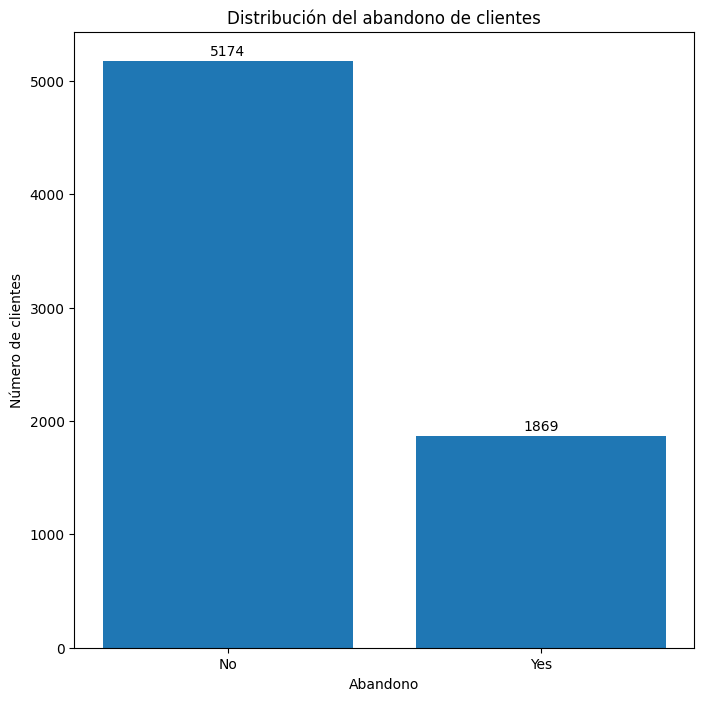

In [11]:
import matplotlib.pyplot as plt

conteo = df["Abandono"].value_counts()

plt.figure(figsize=(8,8))
barras = plt.bar(conteo.index, conteo.values)

plt.title("Distribución del abandono de clientes")
plt.xlabel("Abandono")
plt.ylabel("Número de clientes")

# Mostrar el valor encima de cada barra
for barra in barras:
    altura = barra.get_height()
    plt.text(
        barra.get_x() + barra.get_width()/2,
        altura + 50,
        f"{int(altura)}",
        ha="center"
    )

plt.show()

### Interpretación y conclusión

La distribución de la variable objetivo muestra que la mayoría de los clientes permanecen en la compañía (**5.174 clientes**), mientras que **1.869 clientes** han abandonado el servicio, lo que representa un **26,54 %** del total. Aunque existe un cierto desbalance entre ambas clases, la tasa de abandono es lo suficientemente elevada como para considerarla un problema de negocio relevante, justificando el desarrollo de un modelo predictivo que permita identificar a los clientes con mayor riesgo de churn.

## 4. Perfil del cliente
### 4.1 Género

### Pregunta de negocio

¿Existe alguna diferencia en la probabilidad de abandono entre hombres y mujeres?

Analizar esta variable permitirá comprobar si el género influye en el comportamiento de los clientes o si, por el contrario, el abandono está asociado a otros factores más relevantes.

In [12]:
tabla_porcentajes("Genero")

Abandono,No,Yes
Genero,,
Hombre,73.84,26.16
Mujer,73.08,26.92


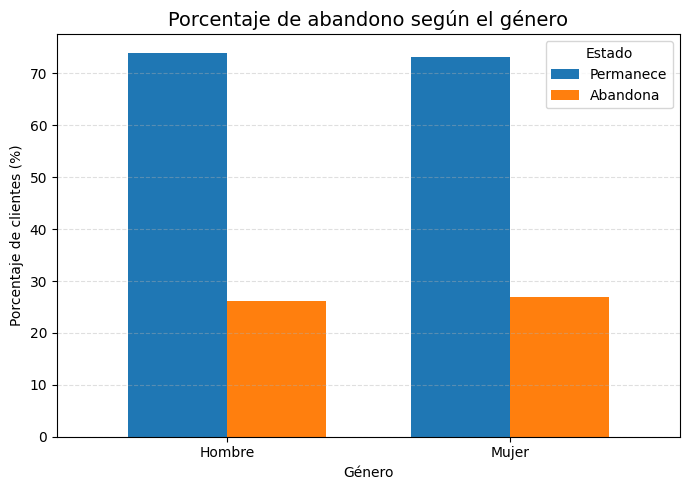

In [13]:
import matplotlib.pyplot as plt

# Obtener la tabla de porcentajes
tabla = tabla_porcentajes("Genero")

# Crear el gráfico
tabla.plot(
    kind="bar",
    figsize=(7, 5),
    width=0.7
)

# Personalización
plt.title("Porcentaje de abandono según el género", fontsize=14)
plt.xlabel("Género")
plt.ylabel("Porcentaje de clientes (%)")
plt.xticks(rotation=0)
plt.legend(["Permanece", "Abandona"], title="Estado")
plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

### Interpretación y conclusión

La distribución del abandono es muy similar entre hombres y mujeres, sin diferencias apreciables entre ambos grupos. Esto indica que el género no parece ser un factor relevante para explicar el churn y, previsiblemente, tendrá una capacidad predictiva limitada en los modelos de Machine Learning.

## 4.2 Adulto mayor

### Pregunta de negocio

¿Existe una relación entre ser Adulto Mayor y la probabilidad de abandono del servicio?

Identificar este comportamiento permitirá determinar si este segmento de clientes presenta un mayor riesgo de churn y requiere estrategias de retención específicas.

In [14]:
tabla_porcentajes("Adulto_Mayor")

Abandono,No,Yes
Adulto_Mayor,,
0,76.39,23.61
1,58.32,41.68


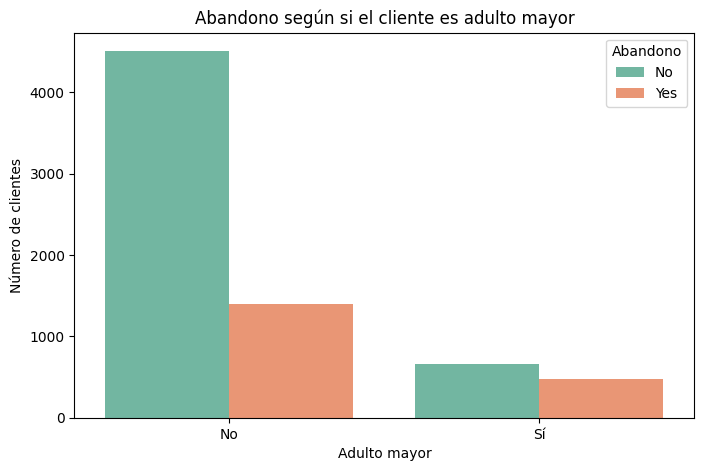

In [15]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Adulto_Mayor",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según si el cliente es adulto mayor")
plt.xlabel("Adulto mayor")
plt.ylabel("Número de clientes")
plt.xticks([0, 1], ["No", "Sí"])
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes clasificados como **adultos mayores** presentan una mayor tasa de abandono (**41,68 %**) que aquellos que no pertenecen a este grupo (**23,61 %**). Esta diferencia sugiere que la condición de adulto mayor está asociada a un mayor riesgo de churn, por lo que esta variable podría resultar relevante tanto para el análisis del comportamiento de los clientes como para los modelos predictivos.

## 4.3 Tiene pareja

### Pregunta de negocio

¿Tener pareja está relacionado con la probabilidad de abandono del servicio?

Analizar esta variable permitirá comprobar si la situación personal del cliente influye en su permanencia en la compañía o si el abandono depende principalmente de otros factores.

In [16]:
tabla_porcentajes("Tiene_Pareja")

Abandono,No,Yes
Tiene_Pareja,,
No,67.04,32.96
Yes,80.34,19.66


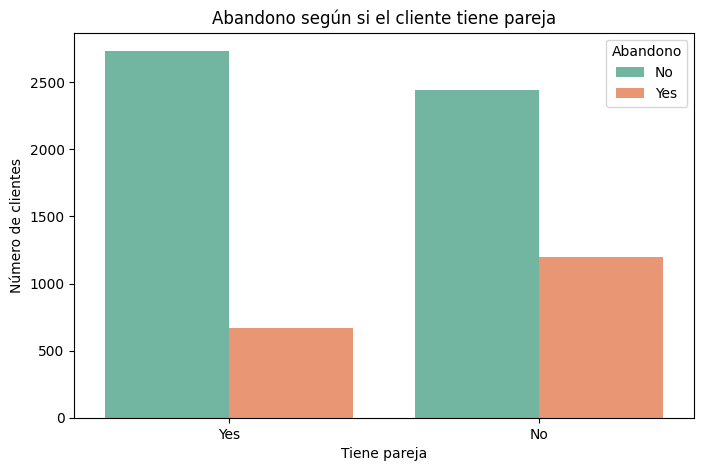

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Tiene_Pareja",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según si el cliente tiene pareja")
plt.xlabel("Tiene pareja")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no tienen pareja** presentan una tasa de abandono del **32,96 %**, mientras que entre aquellos que **sí tienen pareja** el porcentaje desciende hasta el **19,66 %**. Estos resultados sugieren que tener pareja está asociado con una menor probabilidad de abandono, por lo que esta variable podría aportar información relevante para identificar clientes con mayor riesgo de churn.

## 4.4 Tiene dependientes

### Pregunta de negocio

¿Tener personas dependientes influye en la probabilidad de abandono del servicio?

Este análisis permitirá comprobar si las responsabilidades familiares están asociadas con una mayor fidelidad de los clientes o si no existe una relación significativa con el churn.

In [18]:
tabla_porcentajes("Tiene_Dependientes")

Abandono,No,Yes
Tiene_Dependientes,,
No,68.72,31.28
Yes,84.55,15.45


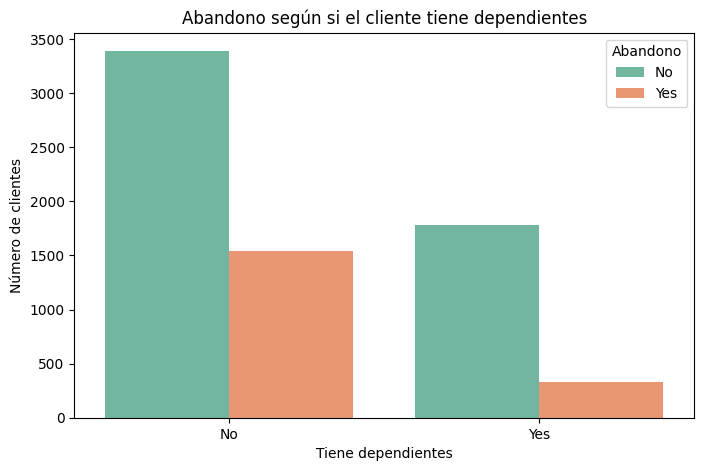

In [19]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Tiene_Dependientes",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según si el cliente tiene dependientes")
plt.xlabel("Tiene dependientes")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no tienen dependientes** presentan una tasa de abandono del **31,28 %**, mientras que entre aquellos que **sí tienen dependientes** el porcentaje se reduce hasta el **15,45 %**. Estos resultados indican que tener dependientes está asociado con una menor probabilidad de abandono, por lo que esta variable podría ser un factor relevante para identificar clientes con mayor riesgo de churn.

### Resumen del bloque: Perfil del cliente

El análisis de las variables demográficas muestra que **el género no parece influir en la probabilidad de abandono**, mientras que factores relacionados con la situación personal del cliente sí presentan diferencias relevantes.

En particular, los **adultos mayores**, los clientes **sin pareja** y aquellos **sin dependientes** registran tasas de abandono superiores, lo que sugiere que estas variables podrían aportar información útil en los modelos predictivos y en la definición de estrategias de fidelización.

## 4.5 Antigüedad

### Pregunta de negocio

¿Existe una relación entre la antigüedad del cliente y la probabilidad de abandono?

La antigüedad puede ser un indicador del nivel de fidelización de un cliente. Analizar esta variable permitirá comprobar si los clientes con menos tiempo en la compañía presentan un mayor riesgo de abandono.

In [20]:
tabla_porcentajes("Antiguedad_Meses")

Abandono,No,Yes
Antiguedad_Meses,,
0,100.00,0.00
1,38.01,61.99
2,48.32,51.68
3,53.00,47.00
4,52.84,47.16
...,...,...
68,91.00,9.00
69,91.58,8.42
70,90.76,9.24


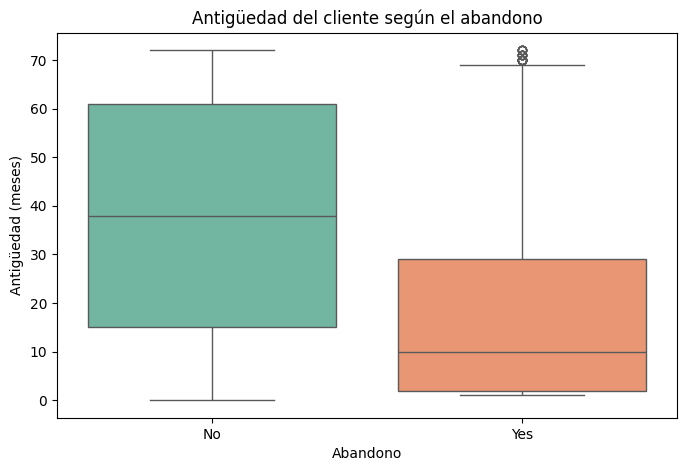

In [21]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Abandono",
    y="Antiguedad_Meses",
    hue="Abandono",
    palette="Set2",
    legend=False
)

plt.title("Antigüedad del cliente según el abandono")
plt.xlabel("Abandono")
plt.ylabel("Antigüedad (meses)")

plt.show()

### Interpretación y conclusión

El boxplot muestra una diferencia clara entre los clientes que abandonan la compañía y aquellos que permanecen. Los clientes que continúan presentan, en general, una mayor antigüedad, mientras que quienes abandonan suelen concentrarse en los primeros meses de relación con la empresa.

Aunque existen algunos casos de clientes con muchos años de antigüedad que también abandonan el servicio, estos son minoritarios. En conjunto, los resultados indican que la antigüedad es una de las variables con mayor capacidad para diferenciar a los clientes con riesgo de churn y probablemente será una de las más relevantes en los modelos predictivos.

# 5. Servicios contratados

## 5.1 Servicio de teléfono

### Pregunta de negocio

¿Disponer del servicio de teléfono está relacionado con la probabilidad de abandono?

Este análisis permitirá comprobar si la contratación del servicio telefónico influye en la permanencia del cliente o si el abandono está asociado a otros servicios ofrecidos por la compañía.

In [22]:
tabla_porcentajes("Servicio_Telefono")

Abandono,No,Yes
Servicio_Telefono,,
No,75.07,24.93
Yes,73.29,26.71


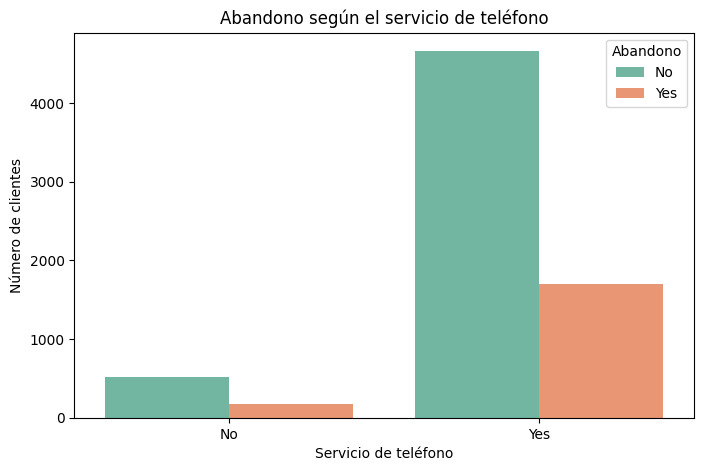

In [23]:
tabla_porcentajes("Servicio_Telefono")

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Servicio_Telefono",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de teléfono")
plt.xlabel("Servicio de teléfono")
plt.ylabel("Número de clientes")

plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

La tasa de abandono es muy similar entre los clientes que disponen del servicio de teléfono (26,71 %) y aquellos que no lo tienen (24,93 %). Aunque los clientes con servicio telefónico presentan un porcentaje de abandono ligeramente superior, la diferencia es reducida.

Estos resultados sugieren que la contratación del servicio de teléfono, por sí sola, no parece ser un factor determinante para explicar el abandono de los clientes. Es probable que otras variables, como el tipo de contrato, los servicios de Internet o la antigüedad, tengan una influencia mucho mayor en el riesgo de churn.

## 5.2 Múltiples líneas

### Pregunta de negocio

¿Disponer de varias líneas telefónicas está relacionado con la probabilidad de abandono?

Este análisis permitirá evaluar si los clientes con múltiples líneas presentan un comportamiento diferente respecto al abandono en comparación con aquellos que disponen de una única línea o no cuentan con este servicio.

In [24]:
tabla_porcentajes("Multiples_Lineas")

Abandono,No,Yes
Multiples_Lineas,,
No,74.96,25.04
No phone service,75.07,24.93
Yes,71.39,28.61


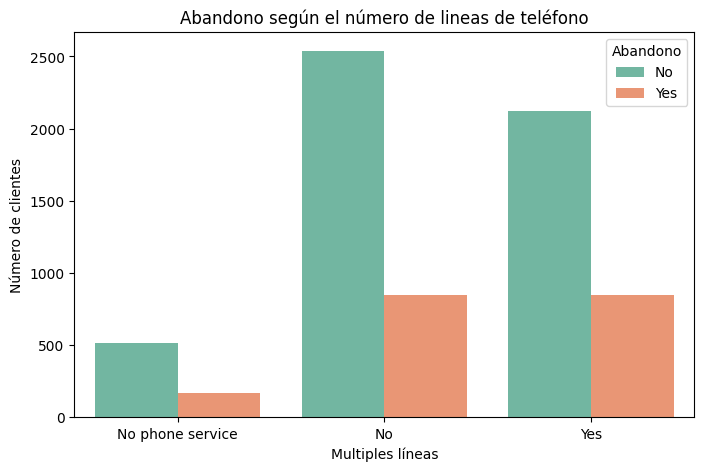

In [25]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Multiples_Lineas",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el número de lineas de teléfono")
plt.xlabel("Multiples líneas")
plt.ylabel("Número de clientes")

plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes con **múltiples líneas telefónicas** presentan una tasa de abandono del **28,61 %**, ligeramente superior a la de aquellos que disponen de una única línea (**25,04 %**) o no cuentan con servicio telefónico (**24,93 %**).

Aunque se aprecia una mayor proporción de abandono entre los clientes con varias líneas, la diferencia no es especialmente acusada. Esto sugiere que esta variable podría aportar cierta información al modelo predictivo, aunque su influencia parece menor que la observada en variables como la antigüedad o las características demográficas analizadas anteriormente.

## 5.3 Servicio de Internet

### Pregunta de negocio

¿El tipo de servicio de Internet contratado está relacionado con la probabilidad de abandono?

El acceso a Internet es uno de los principales servicios ofrecidos por la compañía. Analizar esta variable permitirá comprobar si determinados tipos de conexión presentan una mayor tasa de abandono y podrían requerir estrategias específicas de retención.

In [26]:
tabla_porcentajes("Servicio_Internet")

Abandono,No,Yes
Servicio_Internet,,
DSL,81.04,18.96
Fiber optic,58.11,41.89
No,92.60,7.40


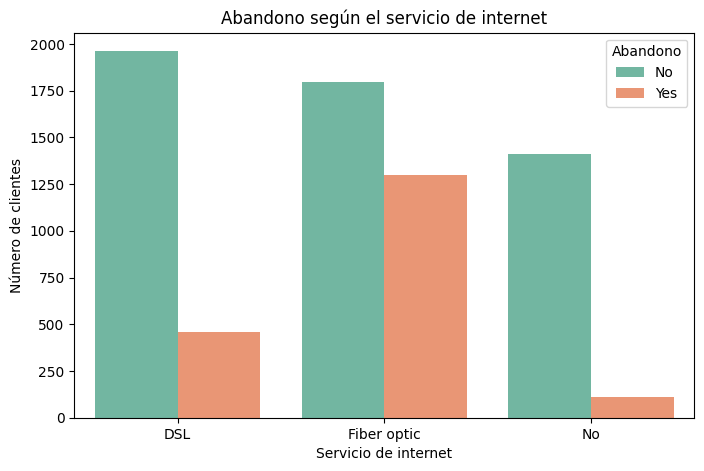

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Servicio_Internet",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de internet")
plt.xlabel("Servicio de internet")
plt.ylabel("Número de clientes")

plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Se observan diferencias muy marcadas en la tasa de abandono según el tipo de servicio de Internet contratado. Los clientes con **fibra óptica** presentan la mayor tasa de abandono (**41,89 %**), muy por encima de quienes disponen de **DSL** (**18,96 %**) o no tienen servicio de Internet (**7,40 %**).

Estos resultados indican que el tipo de conexión a Internet está fuertemente asociado al abandono. En particular, los clientes con fibra óptica constituyen el grupo con mayor riesgo de churn, por lo que esta variable podría desempeñar un papel clave tanto en los modelos predictivos como en el diseño de estrategias de fidelización.

## 5.4 Seguridad online

### Pregunta de negocio

¿La contratación del servicio de seguridad online está relacionada con la probabilidad de abandono?

Este análisis permitirá evaluar si disponer de un servicio de seguridad online está asociado a una mayor fidelización de los clientes o si no existen diferencias significativas en la tasa de abandono.

In [28]:
tabla_porcentajes("Seguridad_Online")

Abandono,No,Yes
Seguridad_Online,,
No,58.23,41.77
No internet service,92.60,7.40
Yes,85.39,14.61


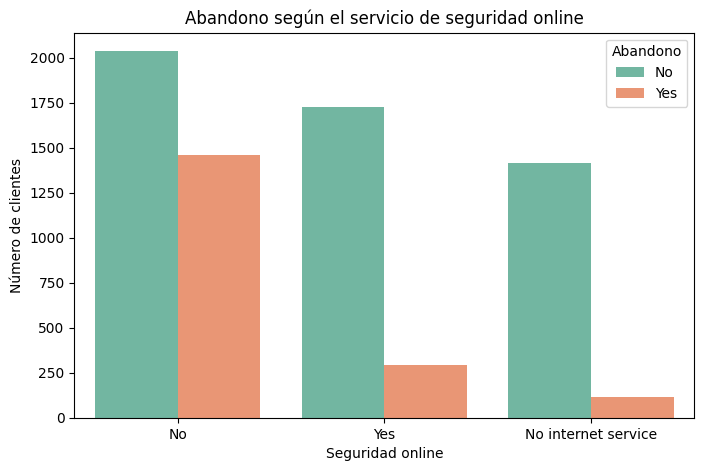

In [29]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Seguridad_Online",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de seguridad online")
plt.xlabel("Seguridad online")
plt.ylabel("Número de clientes")    
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no disponen del servicio de seguridad online** presentan una tasa de abandono del **41,77 %**, mientras que entre quienes sí lo tienen contratado el porcentaje desciende hasta el **14,61 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**), aunque esta categoría debe interpretarse de forma independiente.

Estos resultados muestran una fuerte asociación entre la contratación del servicio de seguridad online y una menor probabilidad de abandono. Esta variable podría desempeñar un papel importante en los modelos predictivos y sugiere que los servicios de valor añadido pueden contribuir a una mayor fidelización de los clientes.

## 5.5 Copia de seguridad online

### Pregunta de negocio

¿La contratación del servicio de copia de seguridad online está relacionada con la probabilidad de abandono?

Este análisis permitirá comprobar si los clientes que disponen de este servicio presentan un comportamiento diferente respecto al abandono en comparación con aquellos que no lo tienen contratado.

In [30]:
tabla_porcentajes("Copia_Seguridad_Online")

Abandono,No,Yes
Copia_Seguridad_Online,,
No,60.07,39.93
No internet service,92.60,7.40
Yes,78.47,21.53


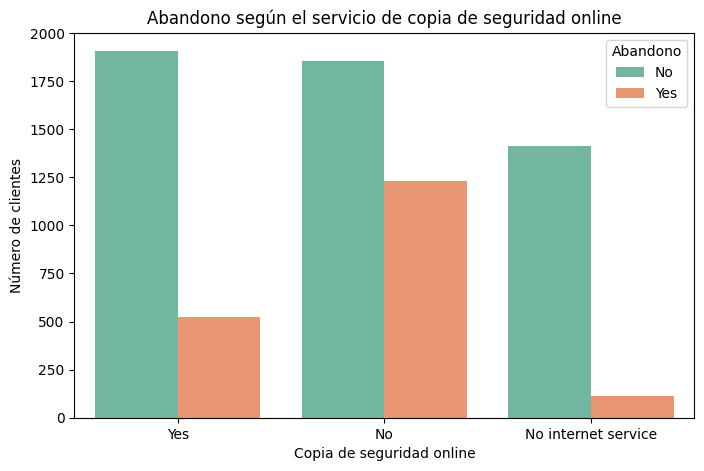

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Copia_Seguridad_Online",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de copia de seguridad online")
plt.xlabel("Copia de seguridad online")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no disponen del servicio de copia de seguridad online** presentan una tasa de abandono del **39,93 %**, mientras que entre quienes sí lo tienen contratado el porcentaje disminuye hasta el **21,53 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**).

Estos resultados muestran que la contratación del servicio de copia de seguridad online está asociada a una menor probabilidad de abandono. Aunque esta variable no explica por sí sola el churn, sí parece aportar información relevante sobre el nivel de vinculación del cliente con la compañía.

## 5.6 Protección del dispositivo

### Pregunta de negocio

¿La contratación del servicio de protección del dispositivo está relacionada con la probabilidad de abandono?

Este análisis permitirá evaluar si los clientes que cuentan con un servicio de protección del dispositivo presentan una mayor fidelización en comparación con aquellos que no lo tienen contratado.

In [32]:
tabla_porcentajes("Proteccion_Dispositivo")

Abandono,No,Yes
Proteccion_Dispositivo,,
No,60.87,39.13
No internet service,92.60,7.40
Yes,77.50,22.50


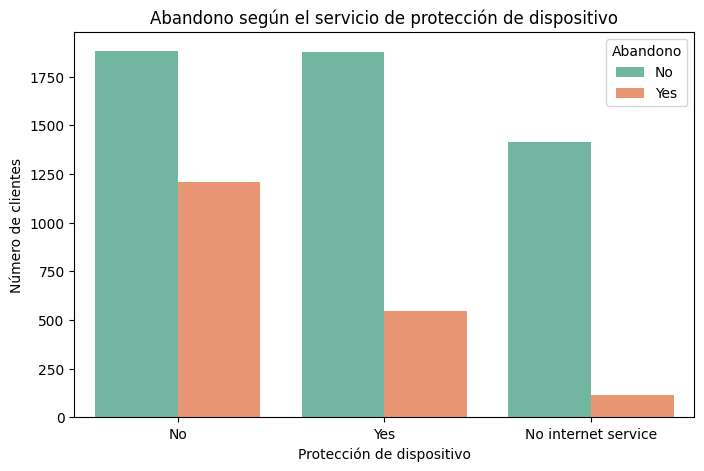

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="Proteccion_Dispositivo",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de protección de dispositivo")
plt.xlabel("Protección de dispositivo")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()


### Interpretación y conclusión

Los clientes que **no disponen del servicio de protección del dispositivo** presentan una tasa de abandono del **39,13 %**, mientras que entre quienes sí lo tienen contratado el porcentaje se reduce hasta el **22,50 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**).

Estos resultados indican que la contratación del servicio de protección del dispositivo está asociada con una menor probabilidad de abandono. Al igual que otros servicios de valor añadido, esta variable podría aportar información relevante para identificar clientes con mayor riesgo de churn.

## 5.7 Soporte técnico

### Pregunta de negocio

¿La contratación del servicio de soporte técnico está relacionada con la probabilidad de abandono?

Este análisis permitirá evaluar si disponer de soporte técnico influye en la permanencia de los clientes o si no existen diferencias significativas en la tasa de abandono.

In [34]:
tabla_porcentajes("Soporte_Tecnico")

Abandono,No,Yes
Soporte_Tecnico,,
No,58.36,41.64
No internet service,92.60,7.40
Yes,84.83,15.17


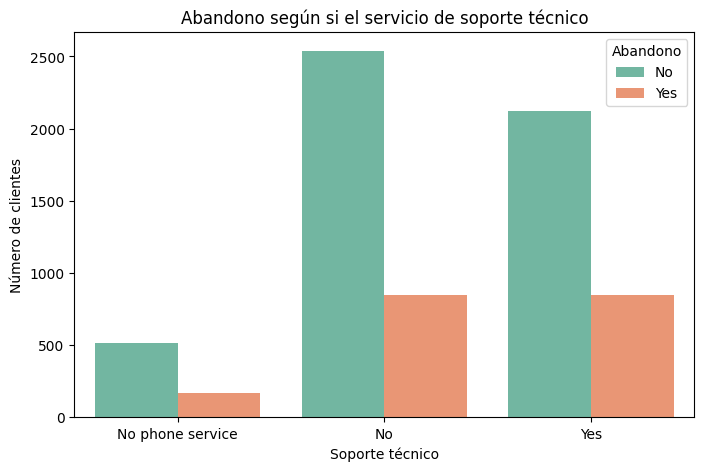

In [35]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Multiples_Lineas",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según si el servicio de soporte técnico")
plt.xlabel("Soporte técnico")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no disponen del servicio de soporte técnico** presentan una tasa de abandono del **41,64 %**, mientras que entre quienes sí lo tienen contratado el porcentaje desciende hasta el **15,17 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**).

Estos resultados muestran una fuerte asociación entre la contratación del servicio de soporte técnico y una menor probabilidad de abandono. Esta variable podría ser especialmente relevante para identificar clientes con mayor riesgo de churn y mejorar la capacidad predictiva del modelo.

## 5.8 Streaming TV

### Pregunta de negocio

¿La contratación del servicio de streaming de televisión está relacionada con la probabilidad de abandono?

Este análisis permitirá comprobar si los clientes que utilizan el servicio de streaming TV presentan un comportamiento diferente respecto al abandono en comparación con aquellos que no lo tienen contratado.

In [36]:
tabla_porcentajes("Streaming_TV")

Abandono,No,Yes
Streaming_TV,,
No,66.48,33.52
No internet service,92.60,7.40
Yes,69.93,30.07


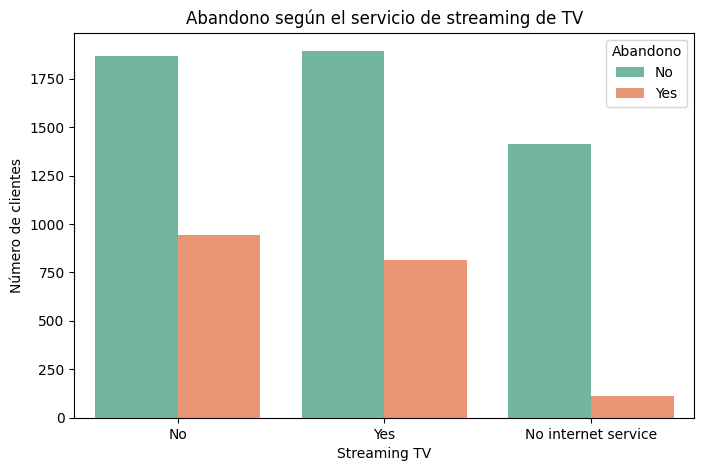

In [37]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Streaming_TV",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de streaming de TV")
plt.xlabel("Streaming TV")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no disponen del servicio de streaming TV** presentan una tasa de abandono del **33,52 %**, mientras que entre quienes sí lo tienen contratado el porcentaje es del **30,07 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**).

Aunque los clientes con streaming TV muestran una tasa de abandono ligeramente inferior, la diferencia respecto a quienes no disponen de este servicio es reducida. Estos resultados sugieren que la contratación de streaming TV, por sí sola, no parece ser un factor determinante para explicar el abandono de los clientes.

## 5.9 Streaming de películas

### Pregunta de negocio

¿La contratación del servicio de streaming de películas está relacionada con la probabilidad de abandono?

Este análisis permitirá evaluar si los clientes que disponen del servicio de streaming de películas presentan un comportamiento diferente respecto al abandono en comparación con aquellos que no lo tienen contratado.

In [38]:
tabla_porcentajes("Streaming_Peliculas")

Abandono,No,Yes
Streaming_Peliculas,,
No,66.32,33.68
No internet service,92.60,7.40
Yes,70.06,29.94


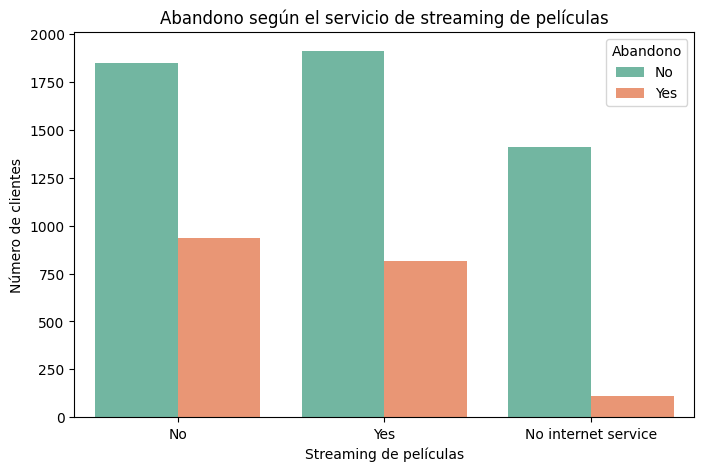

In [39]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Streaming_Peliculas",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el servicio de streaming de películas")
plt.xlabel("Streaming de películas")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **no disponen del servicio de streaming de películas** presentan una tasa de abandono del **33,68 %**, mientras que entre quienes sí lo tienen contratado el porcentaje se reduce al **29,94 %**. Los clientes sin servicio de Internet registran la menor tasa de abandono (**7,40 %**).

Aunque los clientes con este servicio presentan una tasa de abandono ligeramente inferior, la diferencia respecto a quienes no lo tienen contratado es moderada. Esto sugiere que el servicio de streaming de películas, por sí solo, no constituye un factor determinante para explicar el abandono de los clientes.

### Resumen del bloque

El análisis de los servicios contratados muestra diferencias importantes en la tasa de abandono entre los distintos tipos de servicios. En particular, los clientes que disponen de **fibra óptica** presentan un mayor riesgo de churn, mientras que aquellos que tienen contratados servicios como **seguridad online**, **copia de seguridad**, **protección del dispositivo** o **soporte técnico** registran tasas de abandono significativamente inferiores.

Por el contrario, variables como **Servicio_Telefono**, **Multiples_Lineas**, **Streaming_TV** y **Streaming_Peliculas** muestran diferencias mucho menos pronunciadas, lo que sugiere una menor capacidad para explicar el abandono de forma individual.

# 6. Información contractual

## 6.1 Tipo de contrato

### Pregunta de negocio

¿Existe una relación entre el tipo de contrato y la probabilidad de abandono?

El tipo de contrato puede influir directamente en el compromiso del cliente con la compañía. Analizar esta variable permitirá comprobar si determinadas modalidades contractuales presentan un mayor riesgo de churn.

In [40]:
tabla_porcentajes("Tipo_Contrato")

Abandono,No,Yes
Tipo_Contrato,,
Month-to-month,57.29,42.71
One year,88.73,11.27
Two year,97.17,2.83


In [41]:
orden = [
    "Month-to-month",
    "One year",
    "Two year"
]

etiquetas = [
    "Mensual",
    "Un año",
    "Dos años"
]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32668\3358973146.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etiquetas)


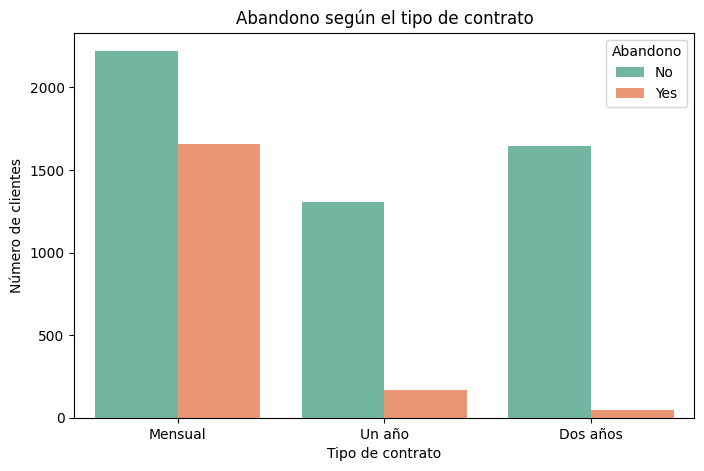

In [42]:
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="Tipo_Contrato",
    hue="Abandono",
    order=orden,
    palette="Set2"
)

plt.title("Abandono según el tipo de contrato")
plt.xlabel("Tipo de contrato")
plt.ylabel("Número de clientes")

ax.set_xticklabels(etiquetas)

plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Se observan diferencias muy marcadas en la tasa de abandono según el tipo de contrato. Los clientes con un contrato **mensual (Month-to-month)** presentan una tasa de abandono del **42,71 %**, muy superior a la de quienes tienen contratos de **un año (11,27 %)** o **dos años (2,83 %)**.

Estos resultados indican que el tipo de contrato está fuertemente asociado al abandono de los clientes. En particular, los contratos mensuales concentran el mayor riesgo de churn, mientras que los contratos de mayor duración parecen favorecer una mayor permanencia en la compañía.

## 6.2 Factura electrónica

### Pregunta de negocio

¿El uso de la factura electrónica está relacionado con la probabilidad de abandono?

Este análisis permitirá comprobar si los clientes que utilizan la factura electrónica presentan un comportamiento diferente respecto al abandono en comparación con aquellos que reciben la factura por otros medios.

In [43]:
tabla_porcentajes("Factura_Electronica")

Abandono,No,Yes
Factura_Electronica,,
No,83.67,16.33
Yes,66.43,33.57


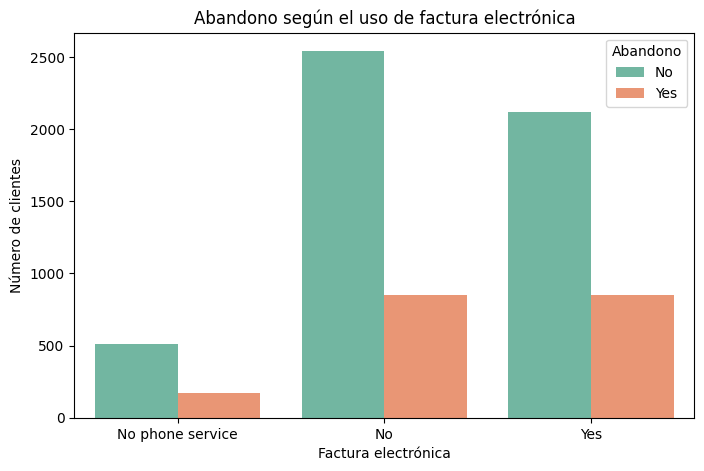

In [44]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Multiples_Lineas",
    hue="Abandono",
    palette="Set2"
)

plt.title("Abandono según el uso de factura electrónica")
plt.xlabel("Factura electrónica")
plt.ylabel("Número de clientes")
plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Los clientes que **utilizan la factura electrónica** presentan una tasa de abandono del **33,57 %**, mientras que entre quienes no la utilizan el porcentaje desciende hasta el **16,33 %**.

Estos resultados muestran una asociación entre el uso de la factura electrónica y una mayor probabilidad de abandono. No obstante, esta relación debe interpretarse con cautela, ya que podría estar influida por otras variables, como el tipo de contrato o el método de pago, que se analizarán a continuación.

## 6.3 Método de pago

### Pregunta de negocio

¿Existe una relación entre el método de pago utilizado por los clientes y la probabilidad de abandono?

Este análisis permitirá identificar si determinados métodos de pago están asociados a una mayor o menor tasa de abandono, lo que podría aportar información útil para comprender el comportamiento de los clientes.

In [45]:
tabla_porcentajes("Metodo_Pago")

Abandono,No,Yes
Metodo_Pago,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [46]:
orden = [
    "Electronic check",
    "Mailed check",
    "Bank transfer (automatic)",
    "Credit card (automatic)"
]

etiquetas = [
    "Cheque\nelectrónico",
    "Cheque por\ncorreo",
    "Transferencia\nautomática",
    "Tarjeta de crédito\nautomática"
]

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32668\2385379982.py:15: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(etiquetas)


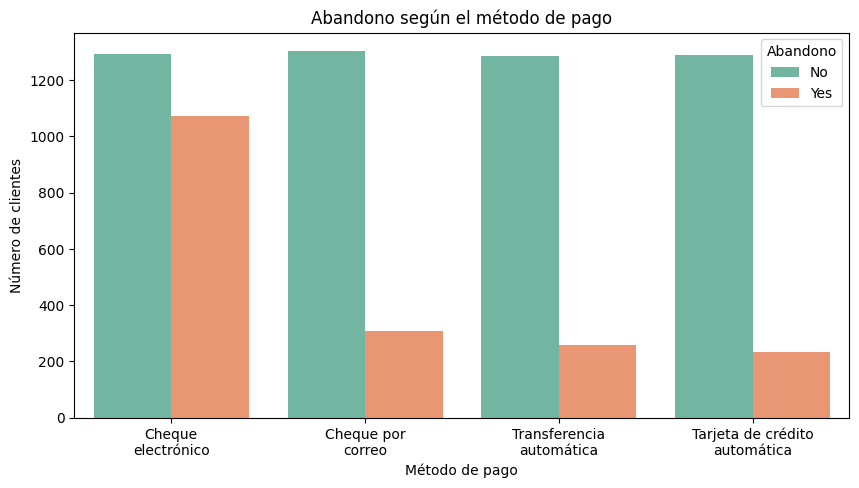

In [47]:
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x="Metodo_Pago",
    hue="Abandono",
    order=orden,
    palette="Set2"
)

plt.title("Abandono según el método de pago")
plt.xlabel("Método de pago")
plt.ylabel("Número de clientes")

ax.set_xticklabels(etiquetas)

plt.legend(title="Abandono")

plt.show()

### Interpretación y conclusión

Se observan diferencias significativas en la tasa de abandono según el método de pago utilizado. Los clientes que realizan sus pagos mediante **cheque electrónico** presentan la mayor tasa de abandono (**45,29 %**), muy por encima de quienes utilizan **cheque enviado por correo (19,11 %)**, **transferencia bancaria automática (16,71 %)** o **tarjeta de crédito con cargo automático (15,24 %)**.

Estos resultados indican que el método de pago está asociado al abandono de los clientes. En particular, el pago mediante **cheque electrónico** concentra el mayor riesgo de churn, mientras que los métodos de pago automáticos presentan las tasas de abandono más bajas.

# 7. Variables económicas

## 7.1 Cargo mensual

### Pregunta de negocio

¿Existe una relación entre el importe del cargo mensual y la probabilidad de abandono?

Este análisis permitirá comprobar si los clientes con cuotas mensuales más elevadas presentan un comportamiento diferente respecto al abandono en comparación con aquellos que pagan importes inferiores.

In [48]:
# Estadísticas descriptivas del cargo mensual según el abandono
df.groupby("Abandono")["Cargo_Mensual"].describe().T.round(2)

Abandono,No,Yes
count,5174.00,1869.00
mean,61.27,74.44
std,31.09,24.67
min,18.25,18.85
25%,25.10,56.15
50%,64.43,79.65
75%,88.40,94.20
max,118.75,118.35


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32668\1329151522.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


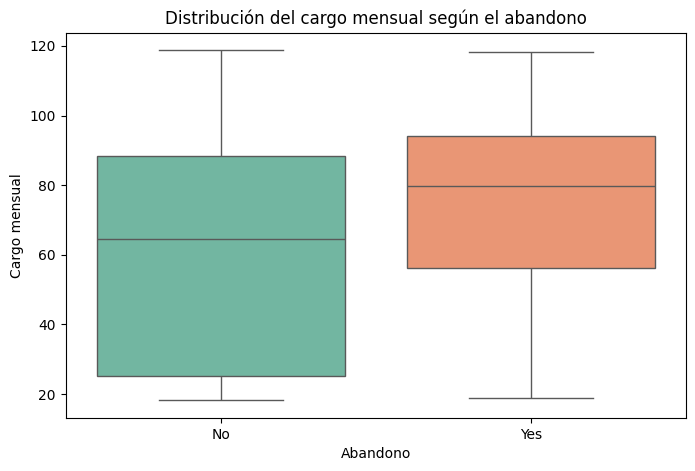

In [49]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Abandono",
    y="Cargo_Mensual",
    palette="Set2"
)

plt.title("Distribución del cargo mensual según el abandono")
plt.xlabel("Abandono")
plt.ylabel("Cargo mensual")

plt.show()

### Interpretación y conclusión

Los clientes que **abandonan la compañía** presentan un **cargo mensual medio de 74,44 €**, superior al de los clientes que permanecen, cuyo importe medio es de **61,27 €**. Esta diferencia también se refleja en la mediana, que alcanza los **79,65 €** para los clientes que abandonan frente a los **64,43 €** de quienes continúan en la compañía.

El boxplot confirma este comportamiento, mostrando que la distribución de los cargos mensuales se encuentra desplazada hacia valores más elevados en el grupo de clientes que abandonan. Estos resultados sugieren que un mayor cargo mensual está asociado con una mayor probabilidad de abandono y que esta variable podría aportar información relevante al modelo predictivo.

## 7.2 Cargos totales

### Pregunta de negocio

¿Existe una relación entre el importe total facturado al cliente y la probabilidad de abandono?

Este análisis permitirá evaluar si el gasto acumulado de los clientes está asociado con una mayor o menor probabilidad de abandono.

In [50]:
# Estadísticas descriptivas de los cargos totales según el abandono
df.groupby("Abandono")["Cargos_Totales"].describe().T.round(2)

Abandono,No,Yes
count,5174.00,1869.00
mean,2549.91,1531.80
std,2329.95,1890.82
min,0.00,18.85
25%,572.90,134.50
50%,1679.52,703.55
75%,4262.85,2331.30
max,8672.45,8684.80


C:\Users\Lenovo\AppData\Local\Temp\ipykernel_32668\822904386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


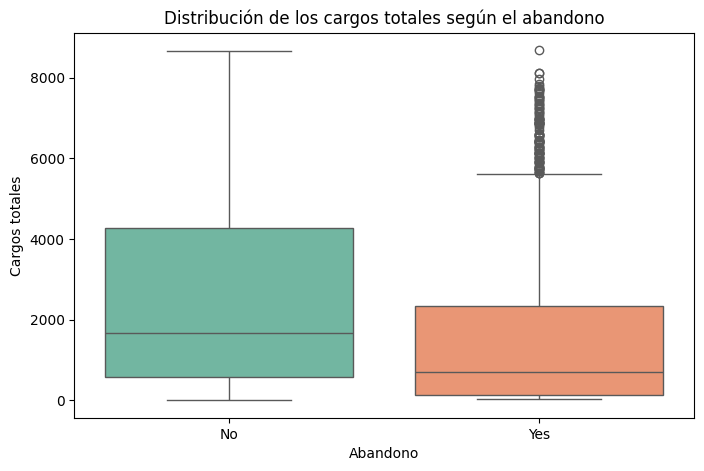

In [51]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Abandono",
    y="Cargos_Totales",
    palette="Set2"
)

plt.title("Distribución de los cargos totales según el abandono")
plt.xlabel("Abandono")
plt.ylabel("Cargos totales")

plt.show()

### Interpretación y conclusión

Los clientes que **abandonan la compañía** presentan unos **cargos totales medios de 1.531,80 €**, considerablemente inferiores a los de los clientes que permanecen, cuyo importe medio asciende a **2.549,91 €**. Esta diferencia también se observa en la mediana, con **703,55 €** frente a **1.679,52 €**, respectivamente.

El boxplot confirma que los clientes que abandonan han acumulado un gasto total menor. Este comportamiento es coherente con el análisis de la antigüedad, ya que los clientes con menor tiempo en la compañía han tenido menos oportunidades de generar un importe acumulado elevado. Por tanto, los cargos totales parecen estar estrechamente relacionados con la permanencia del cliente.

# 8. Conclusiones generales

El análisis exploratorio ha permitido identificar varios factores claramente asociados al abandono de los clientes. Aunque algunas variables, como el género o el servicio de teléfono, apenas muestran diferencias entre los grupos, otras presentan patrones muy marcados que pueden resultar de gran utilidad para el desarrollo del modelo predictivo.

Entre los principales hallazgos destaca la **antigüedad del cliente**, observándose que los clientes con menor tiempo en la compañía presentan una mayor probabilidad de abandono. Asimismo, el **tipo de contrato** muestra una fuerte asociación con el churn, siendo los contratos mensuales los que registran las tasas de abandono más elevadas.

En cuanto a los servicios contratados, los clientes con **fibra óptica** presentan un mayor riesgo de abandono, mientras que la contratación de servicios como **seguridad online**, **copia de seguridad**, **protección del dispositivo** y **soporte técnico** está asociada con una menor probabilidad de churn. Por el contrario, servicios como **Streaming TV** o **Streaming de películas** muestran diferencias mucho menos significativas.

Respecto a las variables económicas, los clientes que abandonan presentan, en promedio, **cargos mensuales más elevados**, pero **cargos totales inferiores**, un resultado coherente con la menor antigüedad observada en este grupo de clientes.

En conjunto, el análisis exploratorio ha permitido comprender mejor el comportamiento de los clientes y detectar las variables con mayor potencial predictivo. Estos resultados servirán como base para la siguiente fase del proyecto, en la que se realizará el preprocesamiento de los datos y la preparación del conjunto de datos para el entrenamiento de modelos de Machine Learning.